In [74]:
import numpy as np
import matplotlib.pyplot as plt
import os

## Serial vs Parallel

In [75]:
parallel_pth: str = "Data/cube_benchmark_data"
serial_pth:   str = "Data/cube_benchmark_data_serial"

parallel_img_pth = os.path.join(parallel_pth, "Images")
parallel_vel_pth = os.path.join(parallel_pth, "Velocities")

serial_img_pth = os.path.join(serial_pth, "Images")
serial_vel_pth = os.path.join(serial_pth, "Velocities")

In [76]:
get_frames = lambda x: sorted([int(i.split("_")[-1].split(".")[0]) for i in x])

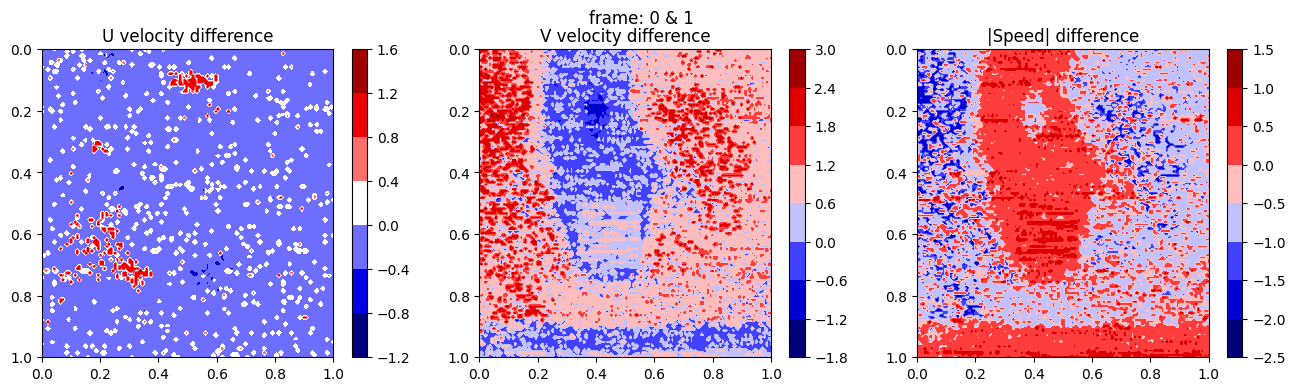

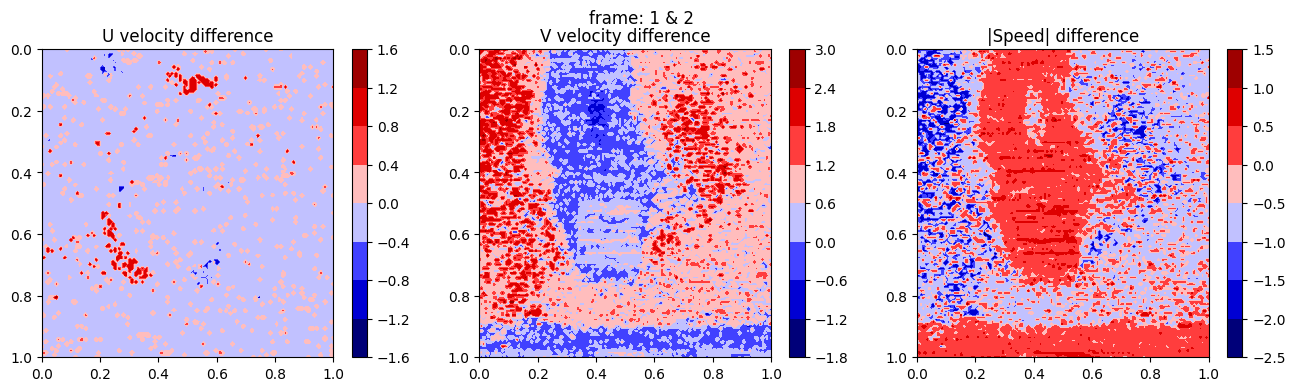

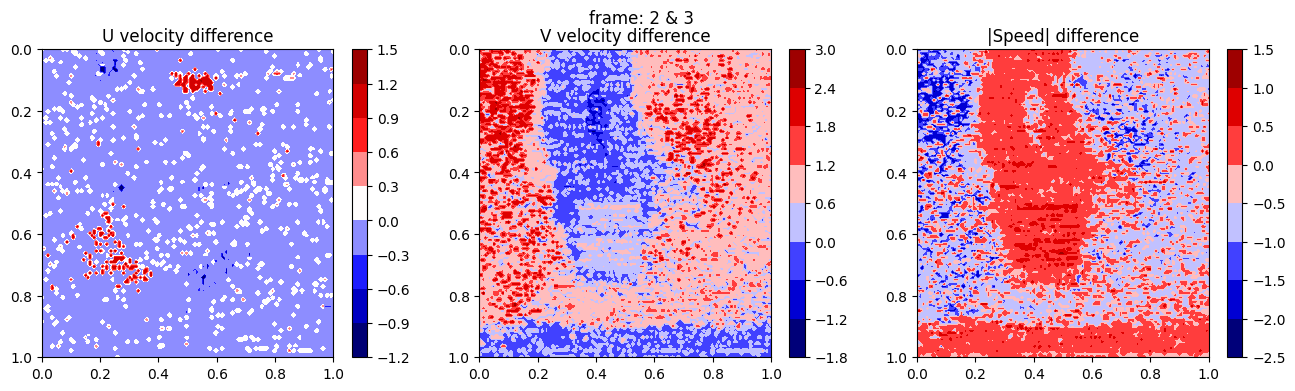

In [ ]:
frames = get_frames(os.listdir(parallel_img_pth))
total_frames = len(frames)

for i in range(total_frames):
    parallel_img = plt.imread(os.path.join(parallel_img_pth, f"img_{frames[i]}.png"))
    serial_img   = plt.imread(os.path.join(serial_img_pth, f"img_{frames[i]}.png"))

    U_parallel = np.loadtxt(os.path.join(parallel_vel_pth, f"U_{frames[i]}.dat"))
    V_parallel = np.loadtxt(os.path.join(parallel_vel_pth, f"V_{frames[i]}.dat"))
    U_parallel /= U_parallel.max()
    V_parallel /= V_parallel.max()

    U_serial = np.loadtxt(os.path.join(serial_vel_pth, f"U_{frames[i]}.dat"))
    V_serial = np.loadtxt(os.path.join(serial_vel_pth, f"V_{frames[i]}.dat"))
    U_serial /= U_serial.max()
    V_serial /= V_serial.max()

    speed_parallel = np.sqrt(U_parallel**2 + V_parallel**2)
    speed_serial = np.sqrt(U_serial**2 + V_serial**2)

    U_diff = U_parallel - U_serial[:-1,:-1]
    V_diff = V_parallel - V_serial[:-1,:-1]
    speed_diff = speed_parallel - speed_serial[:-1,:-1]

    x = np.linspace(0, 1, U_diff.shape[1])
    y = np.linspace(0, 1, U_diff.shape[0])
    X, Y = np.meshgrid(x, y)

    fig, axs = plt.subplots(1, 3, figsize=(16, 4))

    cf1 = axs[0].contourf(X, Y, U_diff, cmap='seismic')
    axs[0].set_title("U velocity difference")
    axs[0].invert_yaxis()
    plt.colorbar(cf1, ax=axs[0])

    cf2 = axs[1].contourf(X, Y, V_diff, cmap='seismic')
    axs[1].set_title("V velocity difference")
    axs[1].invert_yaxis()
    plt.colorbar(cf2, ax=axs[1])

    cf3 = axs[2].contourf(X, Y, speed_diff, cmap='seismic')
    axs[2].set_title("|Speed| difference")
    axs[2].inblob:vscode-webview://12899ku15arnifqb3g5i29jllklf6garu4j6vvfsmq9mivseqhgb/c6eef2be-1abd-4194-9b83-97e848532548vert_yaxis()
    plt.colorbar(cf3, ax=axs[2])

    plt.suptitle(f"frame: {frames[i]} & {frames[i]+1}")

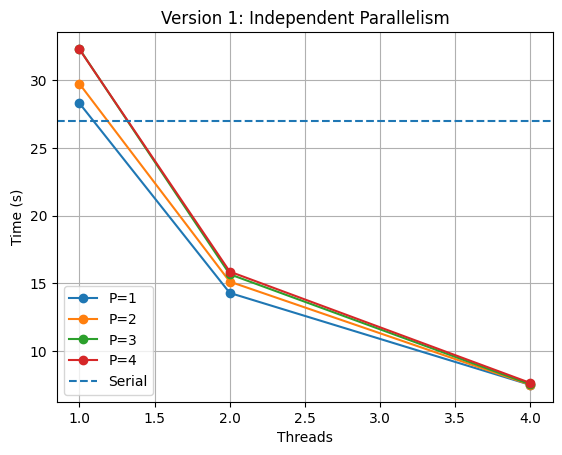

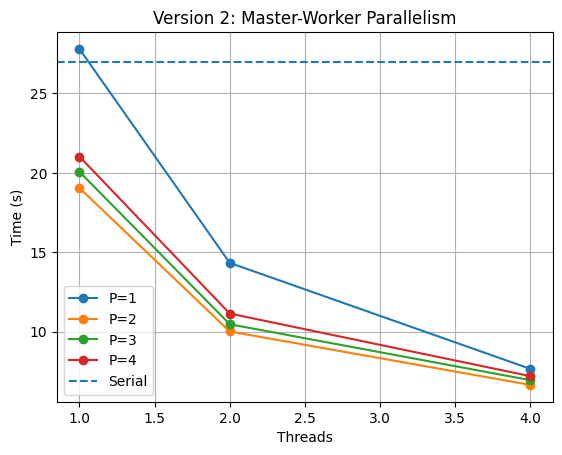

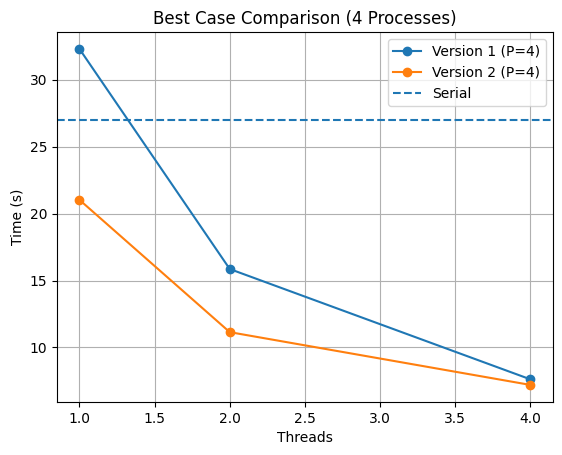

In [93]:
import matplotlib.pyplot as plt

# Threads
threads = [1, 2, 4]

# ---- Version 1 (Independent) ----
v1_p1 = [28.305368, 14.283057, 7.480694]
v1_p2 = [29.743486, 15.116201, 7.483455]
v1_p3 = [32.323621, 15.662668, 7.521608]
v1_p4 = [32.294854, 15.858399, 7.622408]

# ---- Version 2 (Master-Worker) ----
v2_p1 = [27.799022, 14.335604, 7.663507]
v2_p2 = [19.046808, 10.016873, 6.653006]
v2_p3 = [20.069361, 10.471828, 6.952216]
v2_p4 = [21.025117, 11.145304, 7.204322]

# ---- Serial ----
serial_time = 27


# ===============================
# Plot 1: Version 1
# ===============================
plt.figure()
plt.plot(threads, v1_p1, marker='o', label='P=1')
plt.plot(threads, v1_p2, marker='o', label='P=2')
plt.plot(threads, v1_p3, marker='o', label='P=3')
plt.plot(threads, v1_p4, marker='o', label='P=4')
plt.axhline(serial_time, linestyle='--', label='Serial')

plt.xlabel("Threads")
plt.ylabel("Time (s)")
plt.title("Version 1: Independent Parallelism")
plt.legend()
plt.grid()
plt.show()


# ===============================
# Plot 2: Version 2
# ===============================
plt.figure()
plt.plot(threads, v2_p1, marker='o', label='P=1')
plt.plot(threads, v2_p2, marker='o', label='P=2')
plt.plot(threads, v2_p3, marker='o', label='P=3')
plt.plot(threads, v2_p4, marker='o', label='P=4')
plt.axhline(serial_time, linestyle='--', label='Serial')

plt.xlabel("Threads")
plt.ylabel("Time (s)")
plt.title("Version 2: Master-Worker Parallelism")
plt.legend()
plt.grid()
plt.show()


# ===============================
# Plot 3: Best comparison (P=4)
# ===============================
plt.figure()
plt.plot(threads, v1_p4, marker='o', label='Version 1 (P=4)')
plt.plot(threads, v2_p4, marker='o', label='Version 2 (P=4)')
plt.axhline(serial_time, linestyle='--', label='Serial')

plt.xlabel("Threads")
plt.ylabel("Time (s)")
plt.title("Best Case Comparison (4 Processes)")
plt.legend()
plt.grid()
plt.show()

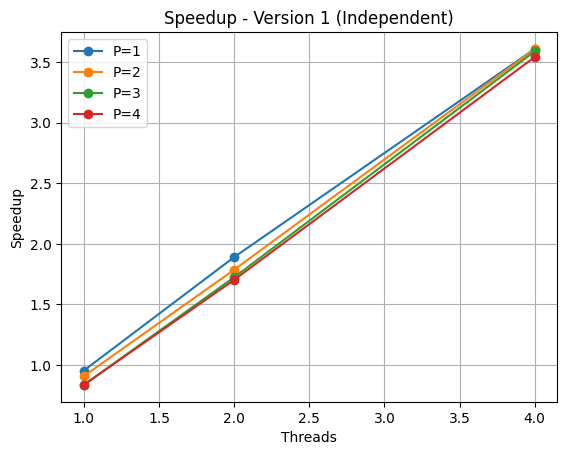

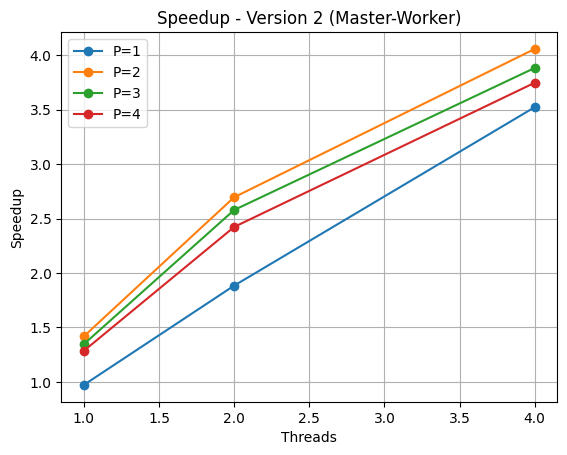

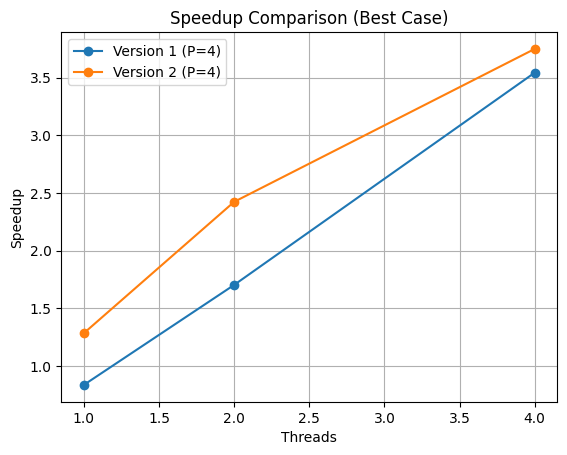

In [95]:
import matplotlib.pyplot as plt

threads = [1, 2, 4]
serial_time = 27

# -------- Version 1 --------
v1_p1 = [28.305368, 14.283057, 7.480694]
v1_p2 = [29.743486, 15.116201, 7.483455]
v1_p3 = [32.323621, 15.662668, 7.521608]
v1_p4 = [32.294854, 15.858399, 7.622408]

# -------- Version 2 --------
v2_p1 = [27.799022, 14.335604, 7.663507]
v2_p2 = [19.046808, 10.016873, 6.653006]
v2_p3 = [20.069361, 10.471828, 6.952216]
v2_p4 = [21.025117, 11.145304, 7.204322]

# Function to compute speedup
def speedup(times):
    return [serial_time / t for t in times]


# ===============================
# Plot 1: Version 1 Speedup
# ===============================
plt.figure()
plt.plot(threads, speedup(v1_p1), marker='o', label='P=1')
plt.plot(threads, speedup(v1_p2), marker='o', label='P=2')
plt.plot(threads, speedup(v1_p3), marker='o', label='P=3')
plt.plot(threads, speedup(v1_p4), marker='o', label='P=4')

# plt.plot(threads, threads, linestyle='--', label='Ideal')  # ideal scaling

plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.title("Speedup - Version 1 (Independent)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# Plot 2: Version 2 Speedup
# ===============================
plt.figure()
plt.plot(threads, speedup(v2_p1), marker='o', label='P=1')
plt.plot(threads, speedup(v2_p2), marker='o', label='P=2')
plt.plot(threads, speedup(v2_p3), marker='o', label='P=3')
plt.plot(threads, speedup(v2_p4), marker='o', label='P=4')

# plt.plot(threads, threads, linestyle='--', label='Ideal')

plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.title("Speedup - Version 2 (Master-Worker)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# Plot 3: Best comparison (P=4)
# ===============================
plt.figure()
plt.plot(threads, speedup(v1_p4), marker='o', label='Version 1 (P=4)')
plt.plot(threads, speedup(v2_p4), marker='o', label='Version 2 (P=4)')
# plt.plot(threads, threads, linestyle='--', label='Ideal')

plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.title("Speedup Comparison (Best Case)")
plt.legend()
plt.grid()
plt.show()

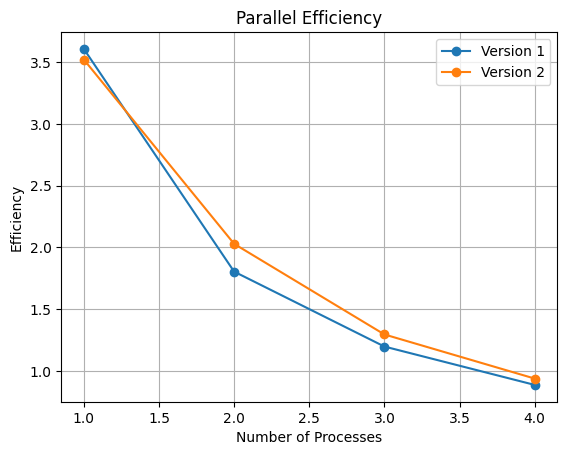

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Serial time
T_serial = 27.0

# Processes
procs = np.array([1, 2, 3, 4])

# Version 1 (best times at 4 threads)
T_v1 = np.array([7.480694, 7.483455, 7.521608, 7.622408])

# Version 2 (best times at 4 threads)
T_v2 = np.array([7.663507, 6.653006, 6.952216, 7.204322])

# Speedup
S_v1 = T_serial / T_v1
S_v2 = T_serial / T_v2

# Efficiency
E_v1 = S_v1 / procs
E_v2 = S_v2 / procs

# Ideal efficiency
ideal = np.ones_like(procs)

# Plot
plt.figure()
plt.plot(procs, E_v1, marker='o', label='Version 1')
plt.plot(procs, E_v2, marker='o', label='Version 2')
# plt.plot(procs, ideal, linestyle='--', label='Ideal')

plt.xlabel('Number of Processes')
plt.ylabel('Efficiency')
plt.title('Parallel Efficiency')
plt.legend()
plt.grid()

plt.show()